In [1]:
import psycopg2
import pandas as pd

In [23]:
conn = psycopg2.connect(
  # Parámetros de conexión
  host = "localhost",  # Dirección del servidor (localhost para local)
  port = "5432" ,      # Puerto por defecto de PostgreSQL
  dbname = "Northwind",  # Nombre de tu base de datos
  user = "postgres",   # Tu nombre de usuario
  password = "1234"  # Tu contraseña
)
conn

print("Conexión exitosa a la base de datos")


Conexión exitosa a la base de datos


¿Cuántos empleados tenemos contratados en 'Global Importaciones'? Indica su id, nombre, apellido, ciudad y país.

In [3]:
sql_query = '''SELECT employee_id, concat_ws(' ', first_name, last_name), city, country 
FROM employees '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,employee_id,concat_ws,city,country
0,1,Nancy Davolio,Seattle,USA
1,2,Andrew Fuller,Tacoma,USA
2,3,Janet Leverling,Kirkland,USA
3,4,Margaret Peacock,Redmond,USA
4,5,Steven Buchanan,London,UK
5,6,Michael Suyama,London,UK
6,7,Robert King,London,UK
7,8,Laura Callahan,Seattle,USA
8,9,Anne Dodsworth,London,UK


¿Qué productos tenemos? Indica el id del producto, id del proveedor, nombre del producto, precio por unidad, unidades en stock, unidades pedidas al


In [14]:
sql_query = '''SELECT
p.product_id,
p.product_name,
s.company_name,
p.unit_price,
p.units_in_stock,
p.units_on_order,
p.discontinued

from products p
left join suppliers s on s.supplier_id=p.supplier_id '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,product_id,product_name,company_name,unit_price,units_in_stock,units_on_order,discontinued
0,1,Chai,"Specialty Biscuits, Ltd.",18.00,39,0,1
1,2,Chang,Exotic Liquids,19.00,17,40,1
2,3,Aniseed Syrup,Exotic Liquids,10.00,13,70,0
3,4,Chef Anton's Cajun Seasoning,New Orleans Cajun Delights,22.00,53,0,0
4,5,Chef Anton's Gumbo Mix,New Orleans Cajun Delights,21.35,0,0,1
...,...,...,...,...,...,...,...
72,73,Röd Kaviar,Svensk Sjöföda AB,15.00,101,0,0
73,74,Longlife Tofu,Tokyo Traders,10.00,4,20,0
74,75,Rhönbräu Klosterbier,Plutzer Lebensmittelgroßmärkte AG,7.75,125,0,0
75,76,Lakkalikööri,Karkki Oy,18.00,57,0,0


¿Tenemos productos descontinuados?. Indica el nombre del producto, y cantidad que nos queda en stock. (El atributo Discontinued es un booleano: si
es igual a 1 el producto ha sido descontinuado.)

In [80]:
sql_query = '''select
product_name,
units_in_stock
from products
where discontinued ='1' '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

InFailedSqlTransaction: transacción abortada, las órdenes serán ignoradas hasta el fin de bloque de transacción


¿Qué proveedores tenemos? Indica el id de la compañía, nombre de la compañía, ciudad y país.

In [42]:
sql_query = '''SELECT
supplier_id,
company_name,
city,
country
from suppliers '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,supplier_id,company_name,city,country
0,1,Exotic Liquids,London,UK
1,2,New Orleans Cajun Delights,New Orleans,USA
2,3,Grandma Kelly's Homestead,Ann Arbor,USA
3,4,Tokyo Traders,Tokyo,Japan
4,5,Cooperativa de Quesos 'Las Cabras',Oviedo,Spain
5,6,Mayumi's,Osaka,Japan
6,7,"Pavlova, Ltd.",Melbourne,Australia
7,8,"Specialty Biscuits, Ltd.",Manchester,UK
8,9,PB Knäckebröd AB,Göteborg,Sweden
9,10,Refrescos Americanas LTDA,Sao Paulo,Brazil


¿Qué pedidos hemos tenido? Indica el número de pedido, id del cliente,id del transportista, dia del pedido, día requerido de llegada y día de llegada real.

In [17]:
sql_query = '''SELECT
order_id
customer_id,
s.shipper_id
order_date,
required_date,
shipped_date
from orders o
left join shippers s on s.shipper_id=o.ship_via '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,customer_id,order_date,required_date,shipped_date
0,10248,3,1996-08-01,1996-07-16
1,10249,1,1996-08-16,1996-07-10
2,10250,2,1996-08-05,1996-07-12
3,10251,1,1996-08-05,1996-07-15
4,10252,2,1996-08-06,1996-07-11
...,...,...,...,...
825,11073,2,1998-06-02,None
826,11074,2,1998-06-03,None
827,11075,2,1998-06-03,None
828,11076,2,1998-06-03,None


¿Cuántos pedidos hemos tenido?

In [18]:
sql_query = '''select 
sum(order_id)
from orders
GROUP by 
order_id '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,sum
0,11038
1,10782
2,10725
3,10423
4,10518
...,...
825,10707
826,10826
827,10371
828,10575


¿Cuántos clientes tenemos? Indica el id del cliente, nombre de la compañía, ciudad y país.

In [19]:
sql_query = '''select 
customer_id,
contact_name,
city,
country
from customers '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,customer_id,contact_name,city,country
0,ALFKI,Maria Anders,Berlin,Germany
1,ANATR,Ana Trujillo,México D.F.,Mexico
2,ANTON,Antonio Moreno,México D.F.,Mexico
3,AROUT,Thomas Hardy,London,UK
4,BERGS,Christina Berglund,Luleå,Sweden
...,...,...,...,...
86,WARTH,Pirkko Koskitalo,Oulu,Finland
87,WELLI,Paula Parente,Resende,Brazil
88,WHITC,Karl Jablonski,Seattle,USA
89,WILMK,Matti Karttunen,Helsinki,Finland


¿Con qué empresas de transporte trabajamos? Indica su id del transportista y el nombre de la compañía.

In [33]:
sql_query = '''SELECT
shipper_id,
company_name
from shippers '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,shipper_id,company_name
0,1,Speedy Express
1,2,United Package
2,3,Federal Shipping
3,4,Alliance Shippers
4,5,UPS
5,6,DHL


¿Cómo son las relaciones de reporte de resultados entre los empleados?

In [43]:
sql_query = '''SELECT
employee_id,
reports_to
from employees '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,employee_id,reports_to
0,1,2.0
1,2,NaN
2,3,2.0
3,4,2.0
4,5,2.0
5,6,5.0
6,7,5.0
7,8,2.0
8,9,5.0


Ejercicio 3. Análisis de la empresa

Haz un estudio de la evolución de los pedidos realizados a lo largo del tiempo.Para ello primero realiza la query necesaria para obtener los meses, años y
pedidos durante cada mes. A continuación crea una línea temporal para verdicha evolución

In [101]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
sql_query = '''SELECT 
    EXTRACT(YEAR FROM order_date) AS year, 
    EXTRACT(MONTH FROM order_date) AS month, 
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY year, month '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,year,month,total_orders
0,1997,3,30
1,1997,12,48
2,1997,11,34
3,1998,4,74
4,1996,8,25
5,1998,2,54
6,1996,9,23
7,1997,5,32
8,1996,10,26
9,1998,5,14


In [65]:
tabla["order_date"] = pd.to_datetime(tabla[['year', 'month']].assign(day=1))


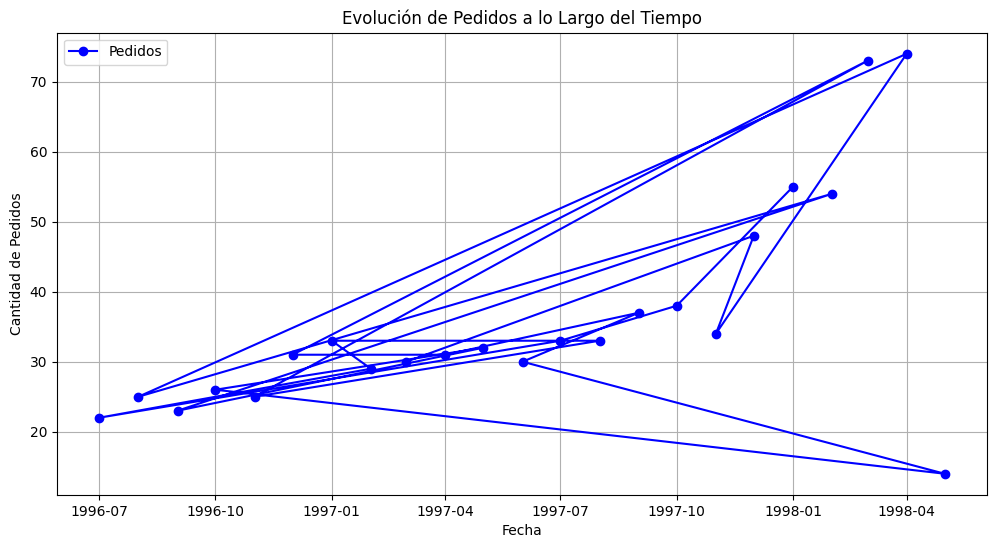

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(tabla["order_date"], tabla["total_orders"], marker="o", linestyle="-", color="b", label="Pedidos")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Pedidos")
plt.title("Evolución de Pedidos a lo Largo del Tiempo")
plt.legend()
plt.grid()
plt.show()

Investiga cuáles son los países donde tenemos más ventas (País origen de la compañía).A raíz de estos datos genera una columna con el continente a partir del
siguiente diccionario

In [6]:
sql_query = '''SELECT 
    o.customer_id,
    c.country,
    SUM(od.quantity) AS total_cantidad
FROM orders o
LEFT JOIN customers c ON c.customer_id = o.customer_id
LEFT JOIN order_details od ON od.order_id = o.order_id
GROUP BY o.customer_id, c.country '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,customer_id,country,total_cantidad
0,HILAA,Venezuela,1096
1,BONAP,France,980
2,LAUGB,Canada,62
3,QUEDE,Brazil,394
4,BSBEV,UK,293
...,...,...,...
84,HUNGC,USA,122
85,FOLKO,Sweden,1234
86,SUPRD,Belgium,1072
87,OCEAN,Argentina,132


In [ ]:
continentes = {'Europe': ['Austria', 'Belgium', 'Denmark', 'Finland', 'France',
'Germany', 'Ireland', 'Italy', 'Norway', 'Poland', 'Portugal', 'Spain', 'Sweden',
'Switzerland', 'UK'],'America': ['Argentina', 'Brazil', 'Canada', 'Mexico', 'USA', 'Venezuela'] }



In [8]:
df_ventas =pd.DataFrame(tabla)

In [11]:
# Asignar continente según el diccionario
def asignar_continente(pais):
    for continente, paises in continentes.items():
        if pais in paises:
            return continente
    return 'Other'

df_ventas['continent'] = df_ventas['country'].apply(asignar_continente)

# Agrupar por continente y sumar ventas
df_continente_ventas = df_ventas.groupby('continent')['total_cantidad'].sum().reset_index()

C:\Users\jmanu\AppData\Local\Temp\ipykernel_19508\2009734895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='continent', y='total_cantidad', data=df_continente_ventas, palette='coolwarm')


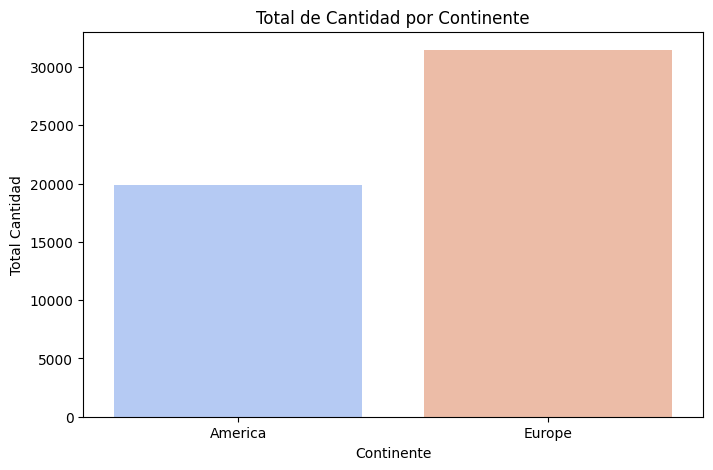

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.barplot(x='continent', y='total_cantidad', data=df_continente_ventas, palette='coolwarm')

plt.xlabel('Continente')
plt.ylabel('Total Cantidad')
plt.title('Total de Cantidad por Continente')
plt.show()

Investiga si la compañía de transporte está relacionada con ello o no. Realiza un boxplot para ver la diferencia de rango intercuartílico

In [38]:
sql_query = '''SELECT 
    customer_id,
    required_date,
    shipped_date,
    s.company_name 

FROM orders o
LEFT JOIN shippers s ON s.shipper_id = o.ship_via
 '''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,customer_id,required_date,shipped_date,company_name
0,VINET,1996-08-01,1996-07-16,Federal Shipping
1,TOMSP,1996-08-16,1996-07-10,Speedy Express
2,HANAR,1996-08-05,1996-07-12,United Package
3,VICTE,1996-08-05,1996-07-15,Speedy Express
4,SUPRD,1996-08-06,1996-07-11,United Package
...,...,...,...,...
825,PERIC,1998-06-02,None,United Package
826,SIMOB,1998-06-03,None,United Package
827,RICSU,1998-06-03,None,United Package
828,BONAP,1998-06-03,None,United Package


In [40]:
import pandas as pd
df_retrasos =pd.DataFrame(tabla)

In [41]:

df_retrasos['required_date'] = pd.to_datetime(df_retrasos['required_date'])
df_retrasos['shipped_date'] = pd.to_datetime(df_retrasos['shipped_date'])


In [42]:
df_retrasos['dias_retrasos'] = (df_retrasos['shipped_date'] - df_retrasos['required_date']).dt.days
df_retrasos['dias_retrasos'].fillna('No enviado', inplace=True)
df_enviado = df_retrasos[df_retrasos['dias_retrasos'] != 'No enviado']

C:\Users\jmanu\AppData\Local\Temp\ipykernel_19508\2857164534.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_retrasos['dias_retrasos'].fillna('No enviado', inplace=True)
C:\Users\jmanu\AppData\Local\Temp\ipykernel_19508\2857164534.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No enviado' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_retrasos['dias_retrasos'].fillna('No enviado', inplac

In [44]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='company_name', y=df_enviado['dias_retrasos'].astype(float), palette='coolwarm')

plt.xlabel('Compañía de Transporte')
plt.ylabel('Días de Retraso')
plt.title('Comparación de Retrasos por Compañía de Transporte')
plt.xticks(rotation=15)
plt.show()

ValueError: Could not interpret value `company_name` for `x`. Value is a string, but `data` was not passed.

<Figure size 1000x500 with 0 Axes>

Hay bastante diferencia entre el precio pagado en cada pedido. Averigüa la distribución media del precio del pedido por país de procedencia del cliente.
Realiza la visualización que creas más conveniente para sacar conclusiones

In [84]:
sql_query = '''SELECT 
cu.country,
AVG(od.unit_price * od.quantity * (1 - od.discount)) AS media_ventas

FROM orders o
LEFT JOIN customers cu on cu.customer_id= o.customer_id
LEFT JOIN order_details od on od.order_id= o.order_id
GROUP BY cu.country
'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,country,media_ventas
0,Argentina,238.797059
1,Spain,333.022222
2,Switzerland,609.474211
3,Italy,297.550093
4,Venezuela,481.446006
5,Belgium,604.015273
6,Norway,358.446876
7,Sweden,561.805566
8,USA,697.683552
9,France,442.164796


In [86]:
import pandas as pd
df =pd.DataFrame(tabla)

In [87]:
df = df.sort_values(by='media_ventas', ascending=False)

C:\Users\jmanu\AppData\Local\Temp\ipykernel_19508\753041062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='media_ventas', y='country', data=df, palette='coolwarm')


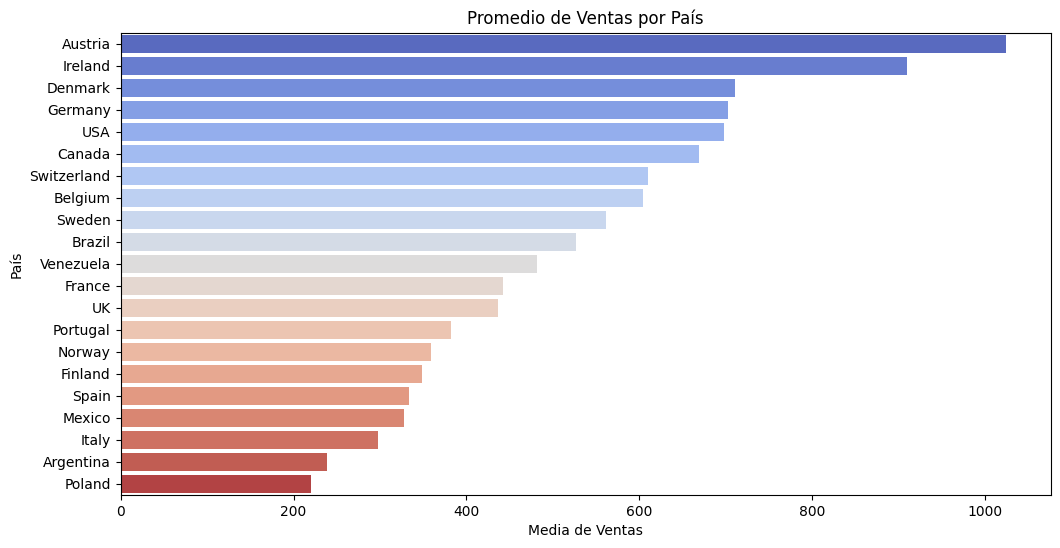

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(x='media_ventas', y='country', data=df, palette='coolwarm')
plt.xlabel('Media de Ventas')
plt.ylabel('País')
plt.title('Promedio de Ventas por País')
plt.show()

Investiga si existen clientes que no hayan pedido nunca. ¿Qué porcentaje de clientes no tienen pedidos registrados?

In [94]:
sql_query = '''SELECT 

COUNT(CASE WHEN o.order_id IS NULL THEN 1 END) * 100.0 / COUNT(DISTINCT c.customer_id) AS porcentaje_sin_pedidos

from customers c

LEFT JOIN orders o on o.customer_id= c.customer_id


'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,porcentaje_sin_pedidos
0,2.1978021978021978


Estudia los productos más demandados e investiga cuáles corre prisa hacerreestock (Los que quedan 20 o menos y no hay unidades pedidas). Realiza la
visualización que creas más conveniente para sacar conclusiones.

In [103]:
sql_query = '''SELECT 
p.product_name,
p.units_in_stock,
p.units_on_order,
od.quantity as "cantidad_vendida"
from products p
left join order_details od on od.product_id = p.product_id
where units_in_stock <20 and units_on_order=0
order by od.quantity desc

'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,product_name,units_in_stock,units_on_order,cantidad_vendida
0,Perth Pasties,0,0,120
1,Camembert Pierrot,19,0,100
2,Alice Mutton,0,0,100
3,Uncle Bob's Organic Dried Pears,15,0,90
4,Camembert Pierrot,19,0,84
...,...,...,...,...
371,Nord-Ost Matjeshering,10,0,2
372,Camembert Pierrot,19,0,2
373,Mozzarella di Giovanni,14,0,1
374,Uncle Bob's Organic Dried Pears,15,0,1


In [104]:
import pandas as pd
df =pd.DataFrame(tabla)

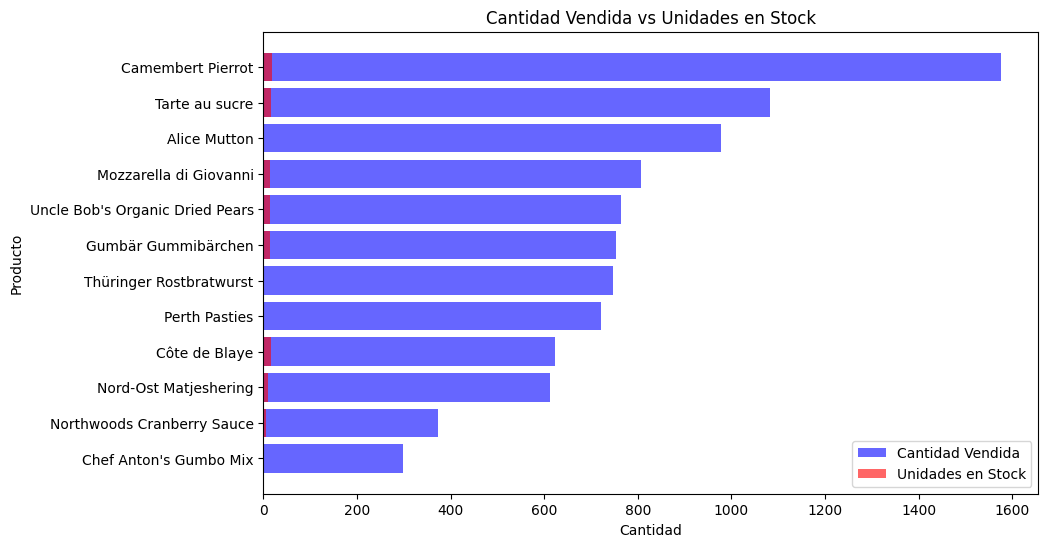

In [ ]:

df_grouped = df.groupby("product_name").agg({"cantidad_vendida": "sum", "units_in_stock": "max"}).reset_index()

df_grouped = df_grouped.sort_values(by="cantidad_vendida", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_grouped["product_name"], df_grouped["cantidad_vendida"], label="Cantidad Vendida", color="blue", alpha=0.6)
ax.barh(df_grouped["product_name"], df_grouped["units_in_stock"], label="Unidades en Stock", color="red", alpha=0.6)

ax.set_xlabel("Cantidad")
ax.set_ylabel("Producto")
ax.set_title("Cantidad Vendida vs Unidades en Stock")
ax.legend()
plt.gca().invert_yaxis()  # Invertir el eje Y para que el más vendido esté arriba

plt.show()

Ejercicio 4. Queries Avanzadas

Quiere saber cuándo fue la última vez que se pidió un producto de cada categoría.

In [122]:
sql_query = '''SELECT 
c.category_name,
MAX(order_date) as ultima_fecha

from categories c
left join products p on c.category_id = p.category_id
left join order_details od on p.product_id = od.product_id
left join orders o on od.order_id = o.order_id

GROUP BY c.category_name
order by ultima_fecha DESC

'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,category_name,ultima_fecha
0,Beverages,1998-05-06
1,Produce,1998-05-06
2,Condiments,1998-05-06
3,Grains/Cereals,1998-05-06
4,Meat/Poultry,1998-05-06
5,Confections,1998-05-06
6,Dairy Products,1998-05-06
7,Seafood,1998-05-06


Necesita saber si existe algún producto que nunca se haya vendido por su precio original.

In [132]:
sql_query = '''SELECT 
p.product_name
order_date


from order_details od
left join products p on p.product_id = od.product_id
left join orders o on o.order_id = od.order_id

GROUP BY order_date, p.product_name
HAVING COUNT(*) >0
AND SUM(CASE WHEN od.unit_price = p.unit_price THEN 1 ELSE 0 END) = 0


'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,order_date
0,Rhönbräu Klosterbier
1,Pavlova
2,Scottish Longbreads
3,Rössle Sauerkraut
4,Teatime Chocolate Biscuits
...,...
648,Manjimup Dried Apples
649,Geitost
650,Nord-Ost Matjeshering
651,Queso Cabrales


Quiere tener toda la información necesaria para poder identificar un tipo de
producto. En concreto, tienen especial interés por los productos con categoría
"Confections". Devuelve el ID del producto, el nombre del producto y su ID de
categoría.

In [ ]:

sql_query = '''SELECT 
p.product_id,
p.product_name,
c.category_id

from products p
left join categories c on c.category_id = p.category_id


where c.category_name = 'Confections'

'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

df =pd.DataFrame(tabla)


,product_id,product_name,category_id
0,16,Pavlova,3
1,19,Teatime Chocolate Biscuits,3
2,20,Sir Rodney's Marmalade,3
3,21,Sir Rodney's Scones,3
4,25,NuNuCa Nuß-Nougat-Creme,3
5,26,Gumbär Gummibärchen,3
6,27,Schoggi Schokolade,3
7,47,Zaanse koeken,3
8,48,Chocolade,3
9,49,Maxilaku,3


Quiere saber si existe algún proveedor del que pueda prescindir ya que todos los productos que tiene se encuentran descontinuados.

In [24]:
sql_query = '''SELECT 
s.supplier_id,
s.company_name

from suppliers s
left join products p on p.supplier_id = s.supplier_id
left join order_details od on p.product_id = od.product_id
left join orders o on od.order_id = o.order_id
left join customers cu on o.customer_id = cu.customer_id
GROUP BY s.company_name,s.supplier_id
HAVING COUNT(CASE WHEN p.discontinued = 0 THEN 1 END) = 0


'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla



,supplier_id,company_name
0,10,Refrescos Americanas LTDA


Extraer los clientes que compraron mas de 30 articulos "Chai" en un único pedido

In [25]:
sql_query = '''SELECT 

cu.company_name,
sum(od.quantity),
p.product_name

from customers cu
left join orders o on o.customer_id = cu.customer_id
left join order_details od on od.order_id = o.order_id
left join products p on p.product_id = od.product_id

where p.product_name ='Chai'
GROUP BY cu.company_name,p.product_name
HAVING SUM(od.quantity) > 30



'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,company_name,sum,product_name
0,Wellington Importadora,41,Chai
1,Berglunds snabbköp,35,Chai
2,Seven Seas Imports,40,Chai
3,Lehmanns Marktstand,80,Chai
4,LINO-Delicateses,54,Chai
5,Save-a-lot Markets,130,Chai
6,QUICK-Stop,75,Chai
7,Bottom-Dollar Markets,60,Chai


Indica los clientes cuya suma total de carga en los pedidos sea mayor de 1000

In [26]:
sql_query = '''SELECT 
cu.customer_id,
cu.company_name,
sum(o.freight)


from customers cu
left join orders o on o.customer_id = cu.customer_id

GROUP BY cu.customer_id, cu.company_name
HAVING SUM(o.freight) > 1000


'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

,customer_id,company_name,sum
0,QUEEN,Queen Cozinha,1982.7000
1,RATTC,Rattlesnake Canyon Grocery,2134.2102
2,FRANK,Frankenversand,1403.4398
3,LEHMS,Lehmanns Marktstand,1017.0300
4,QUICK,QUICK-Stop,5605.6304
5,HUNGO,Hungry Owl All-Night Grocers,2755.2400
6,MEREP,Mère Paillarde,1394.2200
7,BONAP,Bon app',1357.8701
8,BERGS,Berglunds snabbköp,1559.5199
9,FOLKO,Folk och fä HB,1678.0802


Desde recursos humanos nos piden seleccionar los nombres de las ciudades con 5 o más empleadas de cara a estudiar la apertura de nuevas oficinas.

In [27]:
sql_query = '''SELECT 
count(employee_id),
city

from employees


GROUP BY city
HAVING count(employee_id) >= 5


'''
cursor = conn.cursor() # Creamos una variable con la que iniciamos el cursor
cursor.execute(sql_query) # Ejecutamos la query
rows = cursor.fetchall() # Creamos una variable con el restultado de la query en forma de lista de tuplas
tabla = pd.DataFrame(rows)# Genereamos un DataFrame a partir de la variable anterior
colnames = [desc[0] for desc in cursor.description] # Recuperamos los nombres de las columnas de la BBDD
tabla = tabla.set_axis(colnames, axis = 1)# Renombramos las columnas del DF creado para que coincidan con las de la BBDD
tabla

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements